# 1) Data Exploration

In [31]:
import urllib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL
import math

from google.cloud import bigquery

from sklearn import set_config
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge

set_config(display='diagram')

## 1.1) Load Data

**All data**

The data comes from this public Big Query dataset `wagon-public-datasets.taxifare`. There are tables with different dataset sizes. 

**Training dates**

- We train the model on data up to `2015-01-01`. We can't access any data beyond that date to train our model.
- For this first iteration, we train the ML model on a **200k randomly sampled subset** (so that everything fits in RAM memory on our laptops).
- We'll train on the full data once we have obtained funds to access some distributed computing.
- This data is available in the Big Query table `wagon-public-datasets.taxifare.raw_200k`.

Note to Engineering: The data is accessible publicly, but you need your own project to query it. Querying incurs a cost, that's why. Fortunately the dataset is small and querying it falls within the free tier that Google offers for BigQuery.

**Fill your `GCP_PROJECT` below 👇**, Then query the historical data (pre-2015), ordered by date (so as to train/test split chronologically more easily) !

To obtain your project id: run `gcloud config get project` in the terminal.

In [2]:
GCP_PROJECT = "lewagon-final"

In [3]:
GCP_PROJECT_WAGON = "wagon-public-datasets"
BQ_DATASET = "taxifare"
RAW_TABLE = "raw_200k"

MIN_DATE = '2009-01-01'
MAX_DATE = '2015-01-01'

COLUMN_NAMES_RAW = (
    'fare_amount',
    'pickup_datetime',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'passenger_count'
)


In [4]:
query = f"""
    SELECT {", ".join(COLUMN_NAMES_RAW)}
    FROM `{GCP_PROJECT_WAGON}`.{BQ_DATASET}.{RAW_TABLE}
    WHERE pickup_datetime BETWEEN '{MIN_DATE}' AND '{MAX_DATE}'
    ORDER BY pickup_datetime
    """
print(query)



    SELECT fare_amount, pickup_datetime, pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude, passenger_count
    FROM `wagon-public-datasets`.taxifare.raw_200k
    WHERE pickup_datetime BETWEEN '2009-01-01' AND '2015-01-01'
    ORDER BY pickup_datetime
    


In [5]:
client = bigquery.Client(project=GCP_PROJECT)
query_job = client.query(query)
result = query_job.result()
df = result.to_dataframe()
df

/Users/Basti/code/SebastianStohrer/taxifare-mlops-intro/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.20,2009-01-01 01:14:44+00:00,-73.982410,40.782397,-73.978177,40.783295,1
1,11.80,2009-01-01 03:51:05+00:00,-74.006797,40.716359,-73.978616,40.752433,2
2,26.60,2009-01-01 04:23:00+00:00,-73.982930,40.742167,-73.896904,40.843012,1
3,19.80,2009-01-01 04:49:52+00:00,-73.983822,40.729471,-73.982300,40.776622,2
4,3.40,2009-01-01 05:04:41+00:00,-74.013008,40.706021,-74.012851,40.702645,1
...,...,...,...,...,...,...,...
90738,14.50,2014-12-31 22:08:00+00:00,-73.980395,40.742585,-73.994602,40.769627,1
90739,9.50,2014-12-31 22:19:11+00:00,-73.962421,40.794752,-73.940646,40.814270,2
90740,74.16,2014-12-31 22:26:27+00:00,-73.783610,40.648637,-74.091878,40.626073,2
90741,8.50,2014-12-31 22:29:09+00:00,-73.995097,40.752067,-73.981982,40.766362,1


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90743 entries, 0 to 90742
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   fare_amount        90743 non-null  float64            
 1   pickup_datetime    90743 non-null  datetime64[us, UTC]
 2   pickup_longitude   90743 non-null  float64            
 3   pickup_latitude    90743 non-null  float64            
 4   dropoff_longitude  90743 non-null  float64            
 5   dropoff_latitude   90743 non-null  float64            
 6   passenger_count    90743 non-null  Int64              
dtypes: Int64(1), datetime64[us, UTC](1), float64(5)
memory usage: 4.9 MB


Data types look all good, as expected because we query from a BigQuery table, and the table schema had the correct data types.

## 1.2) Clean Data

In [7]:
df.shape


(90743, 7)

In [8]:
df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,90743.000000,90743.000000,90743.000000,90743.000000,90743.000000,90743.0
mean,11.184033,-72.515382,39.943378,-72.532666,39.941231,1.683149
std,9.550824,10.696278,8.880565,12.055413,8.878703,1.303741
min,-2.500000,-736.583333,-74.009777,-1749.704532,-74.015157,0.0
25%,6.000000,-73.992067,40.735081,-73.991378,40.734218,1.0
50%,8.500000,-73.981852,40.752687,-73.980203,40.753308,1.0
75%,12.500000,-73.967212,40.767072,-73.963797,40.767990,2.0
max,208.000000,169.972765,1963.515858,169.972765,1963.515858,6.0


Reflections:
1. There seem to be negative fare amounts?
1. Maximum fare amount 208 USD?
1. Passenger count max seems fine. But the minimum: zero passengers?
1. Minimum and maximum longitude and latitudes make no sense.

Note: less than 200k because we only use data pre-2015 for this initial run.

Remove duplicates

In [9]:
df = df.drop_duplicates()
df.shape


(90743, 7)

Remove buggy transactions

In [10]:
df = df.dropna(how='any', axis=0)
df.shape

(90743, 7)

Address issues 1, 2, and 3: negative and too high fares and no passengers:

In [11]:
df = df[df.fare_amount > 0]
df = df[df.fare_amount < 100]
df = df[df.passenger_count > 0]
df.shape


(90391, 7)

Remove geographically irrelevant transactions (rows)

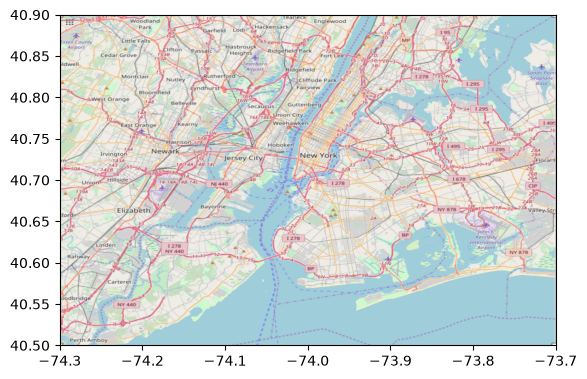

In [12]:
# Let's check NYC bounding boxes
# Load image of NYC map
url = 'https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/nyc_-74.3_-73.7_40.5_40.9.png'
nyc_map = np.array(PIL.Image.open(urllib.request.urlopen(url)))

# Bounding boxes coordinates of the image
bounding_box = (-74.3, -73.7, 40.5, 40.9)

plt.imshow(
    nyc_map,
    extent=bounding_box,
);


In [13]:
df = df[df["pickup_latitude"].between(left=40.5, right=40.9)]
df = df[df["dropoff_latitude"].between(left=40.5, right=40.9)]
df = df[df["pickup_longitude"].between(left=-74.3, right=-73.7)]
df = df[df["dropoff_longitude"].between(left=-74.3, right=-73.7)]


In [14]:
df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,88372.000000,88372.000000,88372.000000,88372.000000,88372.000000,88372.0
mean,11.118241,-73.975777,40.750939,-73.974643,40.751211,1.688736
std,9.159710,0.033856,0.026694,0.033870,0.030529,1.301444
min,2.500000,-74.244137,40.502598,-74.249450,40.501408,1.0
25%,6.000000,-73.992283,40.736658,-73.991570,40.735809,1.0
50%,8.500000,-73.982123,40.753404,-73.980694,40.753947,1.0
75%,12.500000,-73.968456,40.767433,-73.965590,40.768277,2.0
max,97.650000,-73.702580,40.893470,-73.700838,40.898937,6.0


Seems all good now. Good enough to get started.

## 1.3) Visualize Data

Text(0.5, 1.0, 'Distribution of fares')

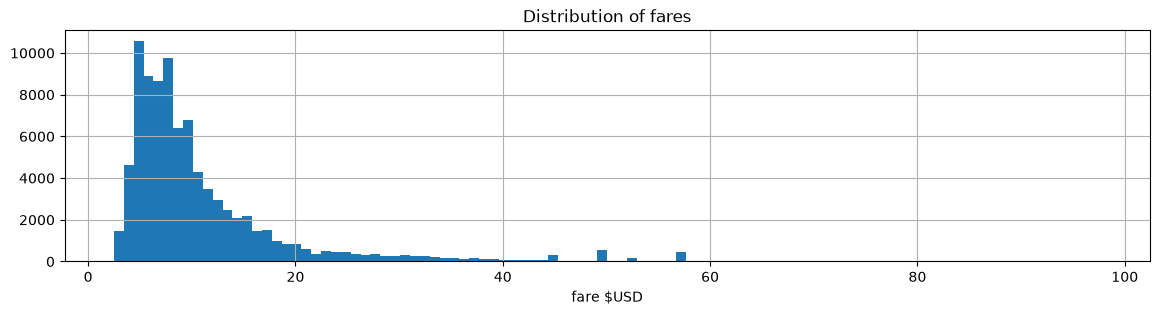

In [15]:
# Plot histogram of fare
df.fare_amount.hist(bins=100, figsize=(14,3))
plt.xlabel('fare $USD')
plt.title('Distribution of fares')


### 1.4) Baseline Score

A baseline model with the most obvious feature: the distance between `pickup` and `dropoff`.

Using the "Manhattan distance" (L1 distance), which computes the sum of horizontal and vertical distances between two points, instead of the diagonal (Euclidean, L2) distance. This seems closer to the reality of New York's street layout.

In [16]:
def manhattan_distance_vectorized(df: pd.DataFrame, start_lat: str, start_lon: str, end_lat: str, end_lon: str) -> dict:
    """
    Calculate the Manhattan distance in km between two points on the earth (specified in decimal degrees).
    Vectorized version for pandas df
    """
    earth_radius = 6371

    lat_1_rad, lon_1_rad = np.radians(df[start_lat]), np.radians(df[start_lon])
    lat_2_rad, lon_2_rad = np.radians(df[end_lat]), np.radians(df[end_lon])

    dlon_rad = lon_2_rad - lon_1_rad
    dlat_rad = lat_2_rad - lat_1_rad

    manhattan_rad = np.abs(dlon_rad) + np.abs(dlat_rad)
    manhattan_km = manhattan_rad * earth_radius

    return manhattan_km

In [17]:
distances = manhattan_distance_vectorized(
    df,
    "pickup_latitude",
    "pickup_longitude",
    "dropoff_latitude",
    "dropoff_longitude"
)
distances

0         0.570541
1         7.144830
2        20.779107
3         5.412191
4         0.392852
           ...    
90738     4.586680
90739     4.591572
90740    36.786840
90741     3.047853
90742     3.395115
Length: 88372, dtype: float64

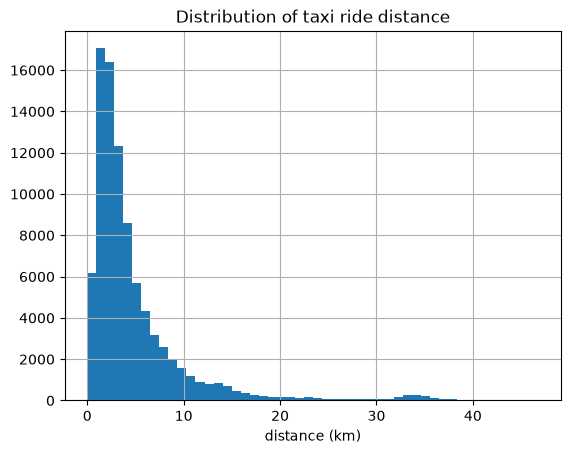

In [18]:
distances.hist(bins=50)
plt.xlabel('distance (km)')
plt.title("Distribution of taxi ride distance");

# 2) Train/Val/Test Split

🚨 We're dealing with timestamped data:
- We need to split train/val/test in a **chronological** manner.
- We don't want to hold too long val or tests sets: macro-economic conditions are changing fast in real life!
- The smaller the `split_ratio`, the more often we'll have to re-train our model
- With a dataset of 6 years, it's perfectly fine to keep 1 month ahead of val, 1 month ahead for test
- In production, this means we shouldn't trust our model performance to extend beyond 1 month in the future

In [19]:
split_ratio = 0.02 # ~1 month for val, ~1 month for test

test_length = int(len(df) * split_ratio)
val_length = int((len(df)-test_length) * split_ratio)
train_length = len(df) - val_length - test_length

df_train = df.iloc[:train_length, :].sample(frac=1) # Shuffle datasets to improve training
df_val = df.iloc[train_length: train_length + val_length, :].sample(frac=1)
df_test = df.iloc[train_length+val_length:, :].sample(frac=1)

print(df_train.shape)
print(df_val.shape)
print(df_test.shape)

assert len(df_train) + len(df_val) + len(df_test) == len(df)

(84873, 7)
(1732, 7)
(1767, 7)


In [20]:
print("Train set date range:")
print(df_train.pickup_datetime.min())
print(df_train.pickup_datetime.max())
print('---')
print("Val set date range:")
print(df_val.pickup_datetime.min())
print(df_val.pickup_datetime.max())
print('---')
print("Test set date range:")
print(df_test.pickup_datetime.min())
print(df_test.pickup_datetime.max())

Train set date range:
2009-01-01 01:14:44+00:00
2014-09-29 21:52:00+00:00
---
Val set date range:
2014-09-30 00:09:00+00:00
2014-11-14 01:10:00+00:00
---
Test set date range:
2014-11-14 02:00:00+00:00
2014-12-31 23:49:25+00:00


In [21]:
X = df.drop("fare_amount", axis=1)
y = df[["fare_amount"]]

X_train = df_train.drop("fare_amount", axis=1)
y_train = df_train["fare_amount"]

X_val = df_val.drop("fare_amount", axis=1)
y_val = df_val["fare_amount"]

X_test = df_test.drop("fare_amount", axis=1)
y_test = df_test["fare_amount"]

### Simple Baseline: Linear Regression based on distance alone

In [22]:
distances_train = manhattan_distance_vectorized(X_train, "pickup_latitude", "pickup_longitude","dropoff_latitude", "dropoff_longitude")
distances_val = manhattan_distance_vectorized(X_val, "pickup_latitude", "pickup_longitude","dropoff_latitude", "dropoff_longitude")
distances_test = manhattan_distance_vectorized(X_test, "pickup_latitude", "pickup_longitude","dropoff_latitude", "dropoff_longitude")

# Convert Series to DataFrame for easier handling
distances_train = pd.DataFrame(distances_train)
distances_val = pd.DataFrame(distances_val)
distances_test = pd.DataFrame(distances_test)


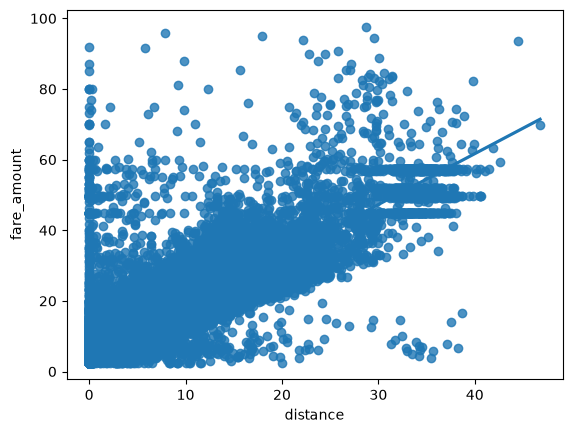

In [23]:
sns.regplot(x=distances_train, y=y_train)
plt.xlabel("distance");


In [24]:
baseline_model = LinearRegression()
baseline_model.fit(pd.DataFrame(distances_train), y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.44]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.086
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1585.64]


In [25]:
baseline_pred_val = baseline_model.predict(distances_val)
baseline_pred_test = baseline_model.predict(distances_test)

baseline_mae_val = np.mean(np.abs(baseline_pred_val - y_val))
baseline_mae_test = np.mean(np.abs(baseline_pred_test - y_test))

print(f'mean taxifare prices on train set = {round(np.mean(y_train), 2)} $')

print(f'🎯 baseline MAE on val set = {round(baseline_mae_val, 2)} $')
print(f'🎯 baseline MAE on test set = {round(baseline_mae_test, 2)} $')


mean taxifare prices on train set = 11.03 $
🎯 baseline MAE on val set = 2.86 $
🎯 baseline MAE on test set = 2.89 $


# 3) Preprocessing Pipeline

In [26]:
set_config(transform_output="pandas")

Note to self: Setting scikit-learn to always output transformed data as Pandas DataFrames. With the small sample this should work fine. The preprocessor is one-hot encoding several columns with many columns, so we'll have lots of `0`s in the outputs. When moving to the larger dataset, I'll have to disable this.

Note to Engineering: This might impact the saved pipeline, so you might have to adapt whatever you are developing afterwards. Let me know.

The dataset has only 5 features (passengers + lon/lat), and at least hundreds of thousands of lines, even with the small sample.

👉 In the next part we "engineer" extra features such as "hour of the day"  
- Adding them will not cause any problem because the huge number of rows will allow our model to learn all weights associated with these multiple features.

❗️ The proposed preprocessor below outputs a **fixed number of features** that is **independent of the training set**. We avoid potential statistical differences due to randomness in the train-test-split by normalizing using fixed numbers, rather than using scalers that depend on statistical measures.

## 3.1) Passenger Preprocessors

Let's analyze passenger numbers

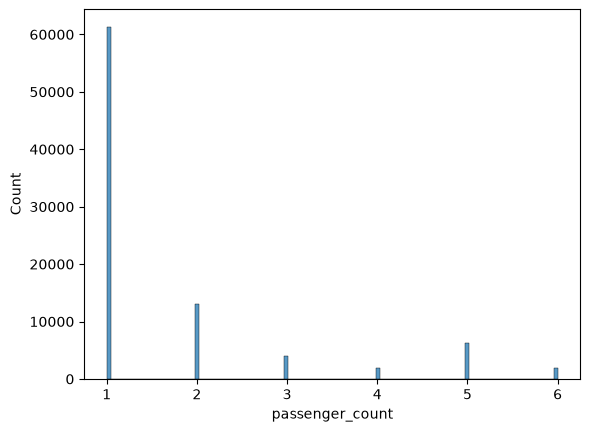

In [27]:
sns.histplot(data=df, x="passenger_count");


In [28]:
# Passenger count pipe
def scale_passenger(p):
    p_min = 0.
    p_max = 8.
    p_scaled = (p - p_min) / (p_max - p_min)
    return p_scaled

passenger_pipe = FunctionTransformer(scale_passenger)

In [29]:
passenger_pipe.fit_transform(X_train[['passenger_count']]).value_counts()


passenger_count
0.125              58832
0.25               12627
0.625               6030
0.375               3825
0.5                 1838
0.75                1721
Name: count, dtype: int64

## 3.2) Time Preprocessor

Let's extract some interesting attributes from the `pickup_datetime`
- hour of the day
- day of the week
- month of the year
- number of days since 2009 (this is way to encode inflation influence)

In [32]:
def transform_time_features(X: pd.DataFrame) -> pd.DataFrame:
    timedelta = (X["pickup_datetime"] - pd.Timestamp('2009-01-01T00:00:00', tz='UTC')) / pd.Timedelta(1,'D')

    pickup_dt = X["pickup_datetime"].dt.tz_convert("America/New_York").dt

    dow = pickup_dt.weekday
    hour = pickup_dt.hour
    month = pickup_dt.month

    hour_sin = np.sin(2 * math.pi / 24 * hour)
    hour_cos = np.cos(2 * math.pi / 24 * hour)

    month_sin = np.sin(2 * math.pi / 24 * month)
    month_cos = np.cos(2 * math.pi / 24 * month)

    return pd.DataFrame({
        'hour_sin': hour_sin,
        'hour_cos': hour_cos,
        'day_of_week': dow,
        'month_sin': month_sin,
        'month_cos': month_cos,
        'timedelta': timedelta
    })

X_time_processed = transform_time_features(X[["pickup_datetime"]])
X_time_processed

,hour_sin,hour_cos,day_of_week,month_sin,month_cos,timedelta
0,-0.866025,5.000000e-01,2,1.224647e-16,-1.000000,0.051898
1,-0.500000,8.660254e-01,2,1.224647e-16,-1.000000,0.160475
2,-0.258819,9.659258e-01,2,1.224647e-16,-1.000000,0.182639
3,-0.258819,9.659258e-01,2,1.224647e-16,-1.000000,0.201296
4,0.000000,1.000000e+00,3,2.588190e-01,0.965926,0.211586
...,...,...,...,...,...,...
90738,-0.965926,-2.588190e-01,2,1.224647e-16,-1.000000,2190.922222
90739,-0.965926,-2.588190e-01,2,1.224647e-16,-1.000000,2190.929988
90740,-0.965926,-2.588190e-01,2,1.224647e-16,-1.000000,2190.935035
90741,-0.965926,-2.588190e-01,2,1.224647e-16,-1.000000,2190.936910


Hour and month are temporal features. Cyclical features like time need some specific preprocessing.

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/02-Prepare-the-dataset/cyclical_feature_engineering.png" alt="Cyclical features" width="1000">

For reference: this [article](https://ianlondon.github.io/posts/encoding-cyclical-features-24-hour-time/) for more details.

Now one-hot-encode `"day of week"` by forcing all 7 categories to be always present in `X_processed` , independent of the sampling. We can do this because we now upfront which days of the week exist. No need to derive it from the data.

This will give us a fixed size of columns for `X_processed` at the end.

In [33]:
days_of_week = np.arange(0, 7, 1)  # days of the week from 0 to 6

day_of_week_encoder = OneHotEncoder(
    categories=[days_of_week],
    handle_unknown="ignore",
    sparse_output=False
)

day_of_week_encoder.fit_transform(X_time_processed[['day_of_week']])


,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
90738,0.0,0.0,1.0,0.0,0.0,0.0,0.0
90739,0.0,0.0,1.0,0.0,0.0,0.0,0.0
90740,0.0,0.0,1.0,0.0,0.0,0.0,0.0
90741,0.0,0.0,1.0,0.0,0.0,0.0,0.0


And combine this with a sort of "Min-Max" re-scaling of the `timedelta` column

In [34]:
print(X_time_processed['timedelta'].min())
print(X_time_processed['timedelta'].max())


0.05189814814814815
2190.992650462963


In [35]:
timedelta_min = 0
timedelta_max = 2190 # Our model may extend in the future. No big deal if the scaled data extend slightly beyond 1.0


In [36]:
def scale_timedelta(timedelta):
    scaled = (timedelta - timedelta_min) / (timedelta_max - timedelta_min)
    return scaled

Time pipeline

In [37]:
time_pipe = make_pipeline(
    FunctionTransformer(transform_time_features),
    make_column_transformer(
        (day_of_week_encoder, ["day_of_week"]),
        (FunctionTransformer(scale_timedelta), ["timedelta"]),
        remainder="passthrough" # keep hour_sin and hour_cos, and month_sin and month_cos
    )
)


☝️ All features approximately centered and scaled

## 3.3) Distance Pipeline

Let's add both the Manhattan distances as feature

In [38]:
lonlat_features = ["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"]

In [39]:
def manhattan_distance_for_pipe(df):
    distance = manhattan_distance_vectorized(df, *lonlat_features)
    return pd.DataFrame({'distance': distance})

In [40]:
def scale_distance(dist):
    dist_min = 0
    dist_max = 100
    scaled = (dist - dist_min) / (dist_max - dist_min)
    return scaled

In [41]:
distance_pipe = make_pipeline(
    FunctionTransformer(manhattan_distance_for_pipe),
    FunctionTransformer(scale_distance)
    )
distance_pipe

distance_pipe.fit_transform(X_train[lonlat_features])

,distance
66778,0.035353
38574,0.031240
45055,0.206264
51213,0.018415
357,0.063861
...,...
48421,0.020507
25036,0.075807
68197,0.377803
77733,0.031645


## 3.5) Full Preprocessing Pipeline

Complete preprocessor

In [42]:
preprocessor = ColumnTransformer(
    [
        ("passenger_preproc", passenger_pipe, ["passenger_count"]),
        ("time_preproc", time_pipe, ["pickup_datetime"]),
        ("dist_preproc", distance_pipe, lonlat_features),
    ],
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('passenger_preproc', ...), ('time_preproc', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer

In [43]:
preprocessor.fit_transform(X_train).describe()

,tmp_col_name_0_0,tmp_col_name_1_0,tmp_col_name_1_1,tmp_col_name_1_2,tmp_col_name_1_3,tmp_col_name_1_4,tmp_col_name_1_5,tmp_col_name_1_6,tmp_col_name_1_7,tmp_col_name_1_8,tmp_col_name_1_9,tmp_col_name_1_10,tmp_col_name_1_11,tmp_col_name_2_0
count,84873.0,84873.000000,84873.000000,84873.000000,84873.000000,84873.000000,84873.000000,84873.000000,84873.000000,8.487300e+04,84873.000000,8.487300e+04,8.487300e+04,84873.000000
mean,0.211182,0.127508,0.143214,0.146171,0.153370,0.164304,0.155962,0.109469,0.477619,-1.579233e-02,-0.205435,6.523926e-01,-4.012249e-02,0.048232
std,0.162611,0.333543,0.350293,0.353280,0.360346,0.370554,0.362822,0.312229,0.274617,7.484674e-01,0.630361,3.081172e-01,6.912631e-01,0.054428
min,0.125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000024,-1.000000e+00,-1.000000,1.224647e-16,-1.000000e+00,0.000000
25%,0.125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.240427,-7.071068e-01,-0.866025,5.000000e-01,-7.071068e-01,0.018136
50%,0.125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.479020,1.224647e-16,-0.258819,7.071068e-01,6.123234e-17,0.031180
75%,0.25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.712766,7.071068e-01,0.258819,9.659258e-01,7.071068e-01,0.056153
max,0.75,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.957950,1.000000e+00,1.000000,1.000000e+00,9.659258e-01,0.467735


☝️ The preprocessor outputs a **fixed** number of features that is independent of the training set. 

☝️ The preprocessor is also  **state-less** (i.e it has no `.fit()` method, only a `.transform()`). It can be seen as a *pure function* $f:X \rightarrow X_{processed}$ without an internal state, as opposed to standard scaling for instance, which has to store "X_train standard deviations" as internal states.

These two features will make work much easier for the ML Engineering team to scale preprocessing to hundreds of GBs. 

# 4) Model

## 4.1) Architecture

In [44]:
linreg = Ridge()

linreg_pipeline = make_pipeline(
    preprocessor, linreg
)

In [45]:
linreg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['pickup_datetime','pickup_longitude','pickup_latitude', 'dropoff_longitude','dropoff_latitude','passenger_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('passenger_preproc', ...), ('time_preproc', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data p

In [ ]:
#export to models as pickle
from pathlib import Path

project_root = Path.cwd().parent
model_path = project_root / "models" / "logreg_pipeline.joblib"

joblib.dump(linreg_pipeline, model_path)

PosixPath('/Users/Basti/code/SebastianStohrer/taxifare-mlops-intro/notebooks')

## 4.2) Performance evaluation

In [46]:
linreg_pred_val = linreg_pipeline.predict(X_val)
linreg_pred_test = linreg_pipeline.predict(X_test)

linreg_mae_val = np.mean(np.abs(linreg_pred_val - y_val))
linreg_mae_test = np.mean(np.abs(linreg_pred_test - y_test))

print(f'mean taxifare prices on train set = {round(np.mean(y_train), 2)} $')

print(f'🎯 linreg MAE on val set = {round(linreg_mae_val, 2)} $')
print(f'🎯 linreg MAE on test set = {round(linreg_mae_test, 2)} $')

mean taxifare prices on train set = 11.03 $
🎯 linreg MAE on val set = 2.94 $
🎯 linreg MAE on test set = 3.06 $


Note to self: Still need to evaluate residuals. But maybe first try to use a better model. Seems the linear regression is not doing great, not even with all the features.